In [ ]:
#The code below goes over all of the fighter data

In [4]:
import requests
from bs4 import BeautifulSoup
import string
import pandas as pd
import re
import os
from datetime import datetime 
from dateutil.parser import parse


url = "http://ufcstats.com/statistics/fighters?char=a&page=all"
page = requests.get(url)
soup = BeautifulSoup(page.content, 'html.parser')

def UCF_Fighter_Links():
    all_hrefs = set()

    # Loop through all characters in the alphabet and collect fighter links
    for char in string.ascii_lowercase:
        url = f"http://ufcstats.com/statistics/fighters?char={char}&page=all"
        response = requests.get(url)
        if response.status_code == 200:
            soup = BeautifulSoup(response.content, 'html.parser')
            fighter_links = soup.find_all('a', class_='b-link_style_black')
            hrefs = set(link['href'] for link in fighter_links)
            all_hrefs.update(hrefs)
        else:
            print(f"Failed to fetch data for character '{char}'")

    return all_hrefs



def calculate_age(date_of_birth):
    today = datetime.today()
    try:
        dob = parse(date_of_birth)
        age = today.year - dob.year - ((today.month, today.day) < (dob.month, dob.day))
        return age
    except ValueError:
        # Handle cases where the date is not parseable
        return None


def UFC_Fighter_Info(fighter_link):
    # Make request to the URL
    page = requests.get(fighter_link)
    soup = BeautifulSoup(page.content, 'html.parser')
    list_items = soup.find_all("li", class_="b-list__box-list-item")
    
    # Extract name
    name_element = soup.find('span', class_='b-content__title-highlight')
    name = name_element.get_text(strip=True) if name_element else None

    # Initialize an empty dictionary to store the information
    info_dict = {}

    # Iterate through each <li> element and extract the information
    for item in list_items:
        # Extract the title and value
        title = item.find("i").get_text(strip=True).replace(":", "")
        value = item.get_text(strip=True, separator=" ").replace(title, "", 1).strip()

        # Clean the value
        clean_value = re.sub(r'[,/]|(lbs\.)', '', value)
        clean_value = re.sub(r'\\', '', clean_value).replace(":", "")
        
        # Store the value in the dictionary
        info_dict[title] = clean_value

    # Insert name into the dictionary
    info_dict['name'] = name

    # Create a DataFrame from the dictionary
    df = pd.DataFrame([info_dict])

    # Reorder columns to have "name" at the start
    df = df[['name'] + [col for col in df.columns if col != 'name']]

    # Rename columns
    column_names_mapping = {
        'Height': 'height',
        'Weight': 'weight',
        'Reach': 'reach',
        'Stance': 'stance',
        'DOB': 'date_of_birth',
        'SLpM': 'SLPM',
        'Str. Acc.': 'Str Acc',
        'SApM': 'SApm',
        'TD Avg.': 'TD Avg',
        'TD Acc.': 'TD Acc',
        'TD Def.': 'TD Def',
        'Sub. Avg.': 'Sub Avg'
    }
    df = df.rename(columns=column_names_mapping)

    return df

def UCF_Fighter_DataFrame_Info(links):
    all_data = pd.DataFrame()
    for link in links:
        df = UFC_Fighter_Info(link)
        all_data = pd.concat([all_data, df], ignore_index=True)

    return all_data


## info = UFC_Fighter_Info('http://ufcstats.com/fighter-details/792be9a24df82ed6')
## print(info)
links = UCF_Fighter_Links()
## Call the function to get the DataFrame
all_data = UCF_Fighter_DataFrame_Info(links)
all_data

,name,height,weight,reach,STANCE,date_of_birth,SLPM,Str Acc,SApm,Str. Def,,TD Avg,TD Acc,TD Def,Sub Avg
0,Roy Jones,--,205,--,,Oct 26 1983,0.00,0%,0.00,0%,,0.00,0%,0%,0.0
1,Zac Pauga,"6' 2""",205,"76""",Orthodox,Feb 25 1988,4.46,62%,2.73,58%,,0.38,7%,100%,0.0
2,Wagner da Conceicao Martins,"6' 7""",390,--,Orthodox,May 19 1978,1.91,37%,5.43,42%,,2.20,100%,100%,0.0
3,Melton Bowen,"6' 0""",225,--,Orthodox,Jul 16 1969,0.00,0%,0.00,0%,,0.00,0%,0%,0.0
4,Michael Mangan,--,155,--,,--,1.94,33%,4.52,46%,,19.35,50%,100%,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4198,Jake Ellenberger,"5' 9""",170,"71""",Orthodox,Mar 28 1985,2.47,39%,2.83,60%,,2.04,47%,86%,0.4
4199,Herman Terrado,--,170,--,,--,0.00,0%,0.00,0%,,0.00,0%,0%,0.0
4200,Thomas Diagne,"6' 1""",154,--,,Sep 03 1983,4.53,48%,4.53,63%,,2.00,100%,66%,0.0
4201,Zabit Magomedsharipov,"6' 1""",145,"73""",Orthodox,Mar 01 1991,4.89,48%,3.00,64%,,5.22,56%,77%,0.8


In [5]:
import pandas as pd
from datetime import datetime
from dateutil.parser import parse

def replace_blank_with_na(df):
    return df.replace(r'^\s*$', 'NA', regex=True)

def calculate_age(date_of_birth):
    today = datetime.today()
    try:
        dob = parse(date_of_birth)
        age = today.year - dob.year - ((today.month, today.day) < (dob.month, dob.day))
        return age
    except (ValueError, TypeError):
        return None

def convert_dob_to_age(df):
    if 'date_of_birth' in df.columns:
        df['age'] = df['date_of_birth'].apply(calculate_age).astype(pd.Int64Dtype())
        df = df.drop(columns=['date_of_birth'])
    else:
        print("The DataFrame does not contain a 'date_of_birth' column.")
    return df

df = replace_blank_with_na(all_data)
df = convert_dob_to_age(all_data)
print("\nDataFrame with Age:")
print(df)


DataFrame with Age:
                             name  height weight reach     STANCE   SLPM  \
0                       Roy Jones      --   205     --              0.00   
1                       Zac Pauga   6' 2"   205    76"   Orthodox   4.46   
2     Wagner da Conceicao Martins   6' 7"   390     --   Orthodox   1.91   
3                    Melton Bowen   6' 0"   225     --   Orthodox   0.00   
4                  Michael Mangan      --   155     --              1.94   
...                           ...     ...    ...   ...        ...    ...   
4198             Jake Ellenberger   5' 9"   170    71"   Orthodox   2.47   
4199               Herman Terrado      --   170     --              0.00   
4200                Thomas Diagne   6' 1"   154     --              4.53   
4201        Zabit Magomedsharipov   6' 1"   145    73"   Orthodox   4.89   
4202              Remo Cardarelli      --   135     --              2.27   

     Str Acc   SApm Str. Def     TD Avg TD Acc TD Def Sub Avg   ag

In [7]:
df.to_csv('C:\\Users\\Lindsay\\Desktop\\Datasets\\fighter_data.csv')

In [ ]:
# The code below goes over the odds per each fight throughout each UFC event

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re


url = "http://www.betmma.tips/mma_betting_favorites_vs_underdogs.php?Org=1"
page = requests.get(url)
soup = BeautifulSoup(page.content, 'html.parser')

def UFC_Event_Links(source):
    fighteventlists = source.find_all('tr')
    fighteventoddslinks = []
    seen_links = set()  # To keep track of seen links
    for row in fighteventlists:
        cols = row.find_all('td')
        if len(cols) >= 2:
            event_link = cols[1].find('a')
            if event_link:
                event_link = event_link['href']
                if 'php?Event' in event_link and event_link not in seen_links:
                    fighteventoddslinks.append('https://www.betmma.tips/' + event_link)
                    seen_links.add(event_link)  # Add the link to the set
    return fighteventoddslinks
def scrape_fight_info(link):
    r = requests.get(link)
    soup = BeautifulSoup(r.content, 'lxml')
    tables = soup.find_all('table')
    
    fight_info_list = []
    seen_names = set()  # Keep track of seen fighter names
    
    # Extract event title
    event_title = soup.find('td', bgcolor="#F7F7F7").find('h1').text.strip()

    for table in tables:
        # Extract fighter names
        fighters = [a.text.strip() for a in table.find_all('a', href=lambda href: href and 'fighter_profile.php' in href)]
        
        # Ensure the number of fighters is even
        if len(fighters) % 2 != 0:
            fighters.pop()  # Remove the last fighter
        
        # Pair up the fighters
        fighter_pairs = [(fighters[i], fighters[i+1]) for i in range(0, len(fighters), 2)]

        # Extract odds
        odds_td = table.find_all('td', bgcolor=lambda color: color in ["#A2FC98", "#FB6A6D"])
        odds_a_b = []
        for odds in odds_td:
            odds_text = odds.get_text(strip=True)
            match = re.search(r'@([\d.]+)', odds_text)
            if match:
                odds_a_b.append(match.group(1))
            else:
                odds_a_b.append(None)  # If no match found, append None
        
        # Filter out None values before extracting odds for Fighter A and Fighter B
        odds_a = None
        for odds in odds_a_b[::2]:
            if odds is not None:
                odds_a = float(odds)
                break
        
        odds_b = None
        for odds in odds_a_b[1::2]:
            if odds is not None:
                odds_b = float(odds)
                break
        
        # Determine the underdog and favorite based on odds, handling None values
        if odds_a is not None and odds_b is not None:
            underdog, favorite = (fighters[0] , fighters[1]) if odds_a < odds_b else (fighters[1] , fighters[0])
        else:
            underdog, favorite = None, None

        # Determine the winner based on color
        winners = []
        for odds in odds_td:
            if odds.get('bgcolor') == '#A2FC98':
                winners.append('Fighter A')  # Fighter A is the winner
            else:
                winners.append('Fighter B')  # Fighter B is the winner

        for (fighter_a, fighter_b), winner in zip(fighter_pairs, winners):
            # Check if either fighter is a duplicate
            if fighter_a in seen_names or fighter_b in seen_names:
                break  # Break from loop if a duplicate is found
            else:
                fight_info_list.append({
                    'Event Title': event_title, 
                    'Fighter A': fighter_a, 
                    'Fighter B': fighter_b, 
                    'Winner': fighter_a if winner == 'Fighter A' else fighter_b, 
                    'Odds A': odds_a, 
                    'Odds B': odds_b,
                    'Underdog': underdog if fighter_a == 'Fighter A' else favorite,
                    'Favorite': favorite if fighter_b == 'Fighter B' else underdog
                })
                seen_names.add(fighter_a)  # Add fighter A to seen names
                seen_names.add(fighter_b)  # Add fighter B to seen names

    return pd.DataFrame(fight_info_list)

def scrape_all_fight_info():
    # Get UFC event links
    fighteventoddslinks = UFC_Event_Links(soup)

    # Scrape fight info for each link
    all_fight_info = []
    for link in fighteventoddslinks:
        fight_info = scrape_fight_info(link)
        all_fight_info.append(fight_info)

    # Concatenate all fight info into one DataFrame
    all_fight_info_df = pd.concat(all_fight_info, ignore_index=True)

    return all_fight_info_df

# Example usage
## info = scrape_fight_info("https://www.betmma.tips/mma_event_betting_history.php?Event=173")
## print(info)

all_fight_event_odds_data = scrape_all_fight_info()
all_fight_event_odds_data

,Event Title,Fighter A,Fighter B,Winner,Odds A,Odds B,Underdog,Favorite
0,UFC 159 - Jones vs. Sonnen,Jon Jones,Chael Sonnen,Jon Jones,1.13,9.00,Chael Sonnen,Jon Jones
1,UFC 159 - Jones vs. Sonnen,Michael Bisping,Alan Belcher,Michael Bisping,1.57,4.50,Alan Belcher,Michael Bisping
2,UFC 159 - Jones vs. Sonnen,Roy Nelson,Cheick Kongo,Roy Nelson,1.43,3.20,Cheick Kongo,Roy Nelson
3,UFC 159 - Jones vs. Sonnen,Phil Davis,Vinny Magalhaes,Phil Davis,1.36,3.55,Vinny Magalhaes,Phil Davis
4,UFC 159 - Jones vs. Sonnen,Pat Healy,Jim Miller,Pat Healy,3.40,1.40,Pat Healy,Jim Miller
...,...,...,...,...,...,...,...,...
4339,UFC Fight Night: Barboza vs. Murphy,Tamires Vidal,Melissa Gatto,Melissa Gatto,4.10,1.29,Tamires Vidal,Melissa Gatto
4340,UFC Fight Night: Barboza vs. Murphy,Abusupiyan Magomedov,Warlley Alves,Abusupiyan Magomedov,1.38,3.75,Warlley Alves,Abusupiyan Magomedov
4341,UFC Fight Night: Barboza vs. Murphy,Ariane Carnelossi,Piera Rodriguez,Ariane Carnelossi,3.05,1.46,Ariane Carnelossi,Piera Rodriguez
4342,UFC Fight Night: Barboza vs. Murphy,Kleydson Rodrigues,Heili Alateng,Heili Alateng,1.67,2.43,Heili Alateng,Kleydson Rodrigues


In [3]:
all_fight_event_odds_data.to_csv('C:\\Users\\Lindsay\\Desktop\\Datasets\\underdogvsfavoriteodds_data.csv')

In [3]:
import requests 
from bs4 import BeautifulSoup
import pandas as pd
import re

baseurl = 'http://ufcstats.com/'

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36'
}
r = requests.get('http://ufcstats.com/statistics/events/completed?page=all')
soup = BeautifulSoup(r.content, 'lxml')


## A function to pull and keep all of the hyperlinks to every known UFC event
def UFC_Event_Links(source): 
    fighteventlist = source.find_all('tr', class_='b-statistics__table-row')
    fighteventlinks = []
    ## Loop through fight event links and search for hrefs in css code
    for fightevent in fighteventlist:
        for link in fightevent.find_all('a', href=True):
            fighteventlinks.append(link['href'])
    return fighteventlinks

def UFC_Fight_Info(link):
    try:
        r = requests.get(link, timeout=10)
        r.raise_for_status()  # Check if the request was successful
    except requests.exceptions.RequestException as e:
        print(f"Error fetching URL: {e}")
        return None
    
    soup = BeautifulSoup(r.content, 'lxml')

    def safe_extract(selector, multiple=False, attr=None, index=0, split_char=None, split_index=-1):
        try:
            if multiple:
                elements = soup.select(selector)
                if elements and index < len(elements):
                    text = elements[index].get_text(strip=True)
                else:
                    return None
            else:
                element = soup.select_one(selector)
                if element:
                    text = element.get_text(strip=True)
                else:
                    return None
            if split_char:
                return text.split(split_char)[split_index].strip()
            return text
        except Exception:
            return None

    title = safe_extract('.b-fight-details__fight-title')
    method = safe_extract('.b-fight-details__text-item_first', split_char=':', split_index=-1)
    round_info = safe_extract('.b-fight-details__text-item', multiple=True, index=1)
    time_info = safe_extract('.b-fight-details__text-item', multiple=True, index=2, split_char=':', split_index=-1)
    referee = safe_extract('.b-fight-details__label:-soup-contains("Referee") + span')
    
    details = soup.select('.b-fight-details__text-item')[4:]

    judge_names = []
    judge_scores = []
    for item in details:
        try:
            name = item.find("span").get_text(strip=True)
            score = item.get_text(strip=True).split(':')[-1].strip()
            score = re.sub(re.escape(name), "", score).strip()
            judge_names.append(name)
            judge_scores.append(score)
        except Exception:
            judge_names.append(None)
            judge_scores.append(None)
    
    for _ in range(3 - len(judge_names)):
        judge_names.append(None)
        judge_scores.append(None)

    fight_info = {
        'Title': title,
        'Method': method,
        'Round': round_info,
        'Time': time_info,
        'Referee': referee,
        'Judge 1 Name': judge_names[0],
        'Judge 1 Score': judge_scores[0],
        'Judge 2 Name': judge_names[1],
        'Judge 2 Score': judge_scores[1],
        'Judge 3 Name': judge_names[2],
        'Judge 3 Score': judge_scores[2],
    }

    return fight_info

def UFC_Fight_Statistics(link):
    fighter_data = {
        'Fighter Name': [], 'Knockdowns': [], 'Significant Strikes': [], 
        'Significant Strike Accuracy': [], 'Total Strikes': [],
        'Takedowns': [], 'Takedown Accuracy': [], 'Submission Attempts': [],
        'Number of Reversals': [], 'Total Control Time': []
    }
    
    try:
        r = requests.get(link, timeout=10)
        r.raise_for_status()
    except requests.exceptions.RequestException as e:
        print(f"Error fetching fight URL: {e}")
        return None
    
    soup = BeautifulSoup(r.content, 'lxml')
    
    details_rows = soup.select('.b-fight-details__table-body .b-fight-details__table-row')
    for row in details_rows:
        cols = row.select('.b-fight-details__table-col')
        for i, col in enumerate(cols):
            col_texts = [p.get_text(strip=True) for p in col.select('.b-fight-details__table-text')]
            if col_texts:
                fighter_data[list(fighter_data.keys())[i]].append(col_texts[0])
                if len(col_texts) > 1:
                    fighter_data[list(fighter_data.keys())[i]].append(col_texts[1])
                else:
                    fighter_data[list(fighter_data.keys())[i]].append('')
    
    max_length = max(len(data) for data in fighter_data.values())
    for key in fighter_data:
        fighter_data[key] += [''] * (max_length - len(fighter_data[key]))
    
    df = pd.DataFrame(fighter_data)
    
    if 'Significant Strikes' in df.columns:
        significant_strikes = df['Significant Strikes'].str.split(' of ', expand=True)
        def safe_int_conversion(x):
            try:
                return int(x)
            except (ValueError, TypeError):
                return 0
        
        df['Significant Strikes Landed'] = significant_strikes[0].apply(safe_int_conversion)
        df['Significant Strikes Attempted'] = significant_strikes[1].apply(safe_int_conversion)
        df.drop(columns=['Significant Strikes'], inplace=True)
    
    if 'Total Strikes' in df.columns:
        total_strikes = df['Total Strikes'].str.split(' of ', expand=True)
        
        df['Total Strikes Landed'] = total_strikes[0].apply(safe_int_conversion)
        df['Total Strikes Attempted'] = total_strikes[1].apply(safe_int_conversion)
        df.drop(columns=['Total Strikes'], inplace=True)
    
    df = df.head(2)
    
    fight_info = UFC_Fight_Info(link)
    if fight_info:
        for key, value in fight_info.items():
            df[key] = value

    return df



def UFC_Fight_Card_Details_Links(link): 
    fight_links = []
    r = requests.get(link)
    soup = BeautifulSoup(r.content, 'html.parser') 
    links = []
    for row in soup.find_all('tr', class_='b-fight-details__table-row'):
        link_attr = row.get('data-link')
        if link_attr:
            links.append(link_attr)

    return links


def UFC_Event_Data_Temp(source):
    all_data = pd.DataFrame()
    rows = source.find_all('tr')
    
    for row in rows:
        img_element = row.find('img', src="http://1e49bc5171d173577ecd-1323f4090557a33db01577564f60846c.r80.cf1.rackcdn.com/next.png")
        if img_element:
            continue  # Skip this row if it contains the specific image tag
        
        link_element = row.find('a', href=True)
        date_element = row.find('span', class_='b-statistics__date')
        
        if link_element and date_element:
            link = link_element['href']
            date = date_element.get_text(strip=True)
            fight_links = UFC_Fight_Card_Details_Links(link)
            
            for fight in fight_links: 
                df = UFC_Fight_Statistics(fight)
                if df is not None:
                    df.insert(0, 'Date', date)
                    df.insert(1, 'UFC Card Link', link)
                    all_data = pd.concat([all_data, df], ignore_index=True)
    
    return all_data
    
fight_info = UFC_Fight_Statistics('http://ufcstats.com/fight-details/44ad16cd4e6c93d7');
print(fight_info)
## all_data =  UFC_Event_Data_Temp(soup);
## card_links = UFC_Fight_Card_Details_Links('http://ufcstats.com/event-details/46baf0f57edfa4df');
## print(card_links)

     Fighter Name Knockdowns Significant Strike Accuracy Takedowns  \
0  Leonard Garcia          0                         19%    0 of 0   
1   Cody McKenzie          0                         55%   5 of 13   

  Takedown Accuracy Submission Attempts Number of Reversals  \
0               ---                   0                   0   
1               38%                   4                   0   

  Total Control Time  Significant Strikes Landed  \
0               0:20                          15   
1               9:11                          30   

   Significant Strikes Attempted  ...                Method      Round  \
0                             77  ...  Decision - Unanimous  Time:5:00   
1                             54  ...  Decision - Unanimous  Time:5:00   

            Time          Referee        Judge 1 Name Judge 1 Score  \
0  3 Rnd (5-5-5)  Dan Miragliotta  Michael Depasquale      28 - 29.   
1  3 Rnd (5-5-5)  Dan Miragliotta  Michael Depasquale      28 - 29.   

  Jud

In [2]:
fight_info.to_csv('C:\\Users\\Lindsay\\Desktop\\Datasets\\info_data.csv')

In [5]:
!pip install fuzzywuzzy[speedup]

   ---------------------------------------- 0.0/98.4 kB ? eta -:--:--
   ------------------------------------- -- 92.2/98.4 kB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 98.4/98.4 kB 1.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 15.9 MB/s eta 0:00:01
   --------------------------- ------------ 1.1/1.7 MB 14.4 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 13.1 MB/s eta 0:00:00


In [17]:
fighter_info = pd.read_csv('C:\\Users\\Lindsay\\Desktop\\Datasets\\fighter_data.csv')
fighter_info.head()

# Function to convert height to inches
def height_to_inches(height):
    try:
        feet, inches = height.split("' ")
        return int(feet) * 12 + int(inches.replace('"', ''))
    except ValueError:
        return None  # Handle any unexpected format

# Function to convert percentage string to float
def percent_to_decimal(percent):
    try:
        return float(percent.strip('%')) / 100
    except ValueError:
        return None  # Handle any unexpected format

# Function to convert reach to float by removing the quotation mark
def reach_to_float(reach):
    try:
        return float(reach.replace('"', ''))
    except ValueError:
        return None  # Handle any unexpected format

# Apply the height conversion
fighter_info['height'] = fighter_info['height'].apply(height_to_inches)

# Apply the reach conversion
fighter_info['reach'] = fighter_info['reach'].apply(reach_to_float)

# List of percentage columns to convert
percentage_columns = ['Str Acc', 'Str. Def', 'TD Acc', 'TD Def']

# Apply the percentage conversion
for column in percentage_columns:
    fighter_info[column] = fighter_info[column].apply(percent_to_decimal)

# Display the modified DataFrame
print(fighter_info.head())

   Unnamed: 0              name  height weight  reach     STANCE  SLPM  \
0           0    Ryuichi Murata    68.0    183   69.0   Orthodox  0.84   
1           1         Tom Aaron    68.0    155   69.0        NaN  0.00   
2           2        Ben Reiter    75.0    185   70.0        NaN  1.80   
3           3  Suman Mokhtarian    68.0    145   72.0   Orthodox  2.21   
4           4     Augusto Sakai    75.0    265   77.0   Orthodox  4.60   

   Str Acc  SApm  Str. Def  TD Avg  TD Acc  TD Def  Sub Avg   age  
0     0.36  1.89      0.50    4.74    0.50    1.00      3.2   NaN  
1     0.00  0.00      0.00    0.00    0.00    0.00      0.0  45.0  
2     0.46  1.53      0.54    7.00    0.43    0.00      0.0  36.0  
3     0.43  6.85      0.48    0.00    0.00    0.00      0.0  31.0  
4     0.49  3.83      0.48    0.23    0.40    0.56      0.0  33.0  


In [18]:
fighter_info.to_csv('C:\\Users\\Lindsay\\Desktop\\Datasets\\fighter_data.csv')

In [1]:
import pandas as pd
from fuzzywuzzy import process
import math

# Load CSV files
odds = pd.read_csv('C:\\Users\\Lindsay\\Desktop\\Datasets\\underdogvsfavoriteodds_data.csv')
fighter_info = pd.read_csv('C:\\Users\\Lindsay\\Desktop\\Datasets\\fighter_data.csv')

# Function to get the closest match for a fighter's name
def get_closest_fighter(name):
    if not isinstance(name, str):
        name = str(name)
    names = fighter_info['name'].tolist()
    closest_match, _ = process.extractOne(name, names)
    return fighter_info[fighter_info['name'] == closest_match].iloc[0]

# Convert relevant columns to numeric
stats_columns = ['height', 'reach', 'SLPM', 'Str Acc', 'SApm', 'Str. Def', 'TD Avg', 'TD Acc', 'TD Def', 'Sub Avg', 'age']
fighter_info[stats_columns] = fighter_info[stats_columns].apply(pd.to_numeric, errors='coerce')

# Function to round down to the hundredth place
def round_down_hundredth(value):
    return math.floor(value * 100) / 100

# Create an empty list to store the results
results = []

# Iterate over each row in the odds dataframe
for index, row in odds.iterrows():
    event = row['Event Title']
    favorite = row['Favorite']
    underdog = row['Underdog']
    winner = row['Winner']
    odds_a = row['Odds A']
    odds_b = row['Odds B']
    
    # Calculate the odds_delta
    odds_delta = abs(odds_a - odds_b)
    
    # Determine if the winner was the favorite or underdog
    if winner == favorite:
        winner_status = 'Favorite'
    elif winner == underdog:
        winner_status = 'Underdog'
    else:
        winner_status = 'Unknown'
    
    # Get stats for favorite and underdog using fuzzy matching
    try:
        favorite_stats = get_closest_fighter(favorite)
        underdog_stats = get_closest_fighter(underdog)
    except IndexError:
        print(f"Stats not found for either {favorite} or {underdog} in event {event}")
        continue
    
    # Calculate the differences in stats (favorite - underdog)
    delta_stats = {
        'event': event,
        'favorite': favorite,
        'underdog': underdog,
        'winner': winner_status,
        'odds_a': odds_a,
        'odds_b': odds_b,
        'odds_delta': odds_delta
    }
    
    for stat in stats_columns:
        favorite_stat = pd.to_numeric(favorite_stats[stat], errors='coerce')
        underdog_stat = pd.to_numeric(underdog_stats[stat], errors='coerce')
        if pd.notnull(favorite_stat) and pd.notnull(underdog_stat):
            delta = favorite_stat - underdog_stat
            delta_stats[f'delta_{stat}'] = round_down_hundredth(delta)
        else:
            delta_stats[f'delta_{stat}'] = None
    
    # Append the result to the results list
    results.append(delta_stats)

# Convert the results list to a DataFrame
results_df = pd.DataFrame(results)

# Display the results
print(results_df)

# Optionally, save the results to a new CSV file
results_df.to_csv('C:\\Users\\Lindsay\\Desktop\\Datasets\\results.csv', index=False)

                                    event              favorite  \
0              UFC 159 - Jones vs. Sonnen             Jon Jones   
1              UFC 159 - Jones vs. Sonnen       Michael Bisping   
2              UFC 159 - Jones vs. Sonnen            Roy Nelson   
3              UFC 159 - Jones vs. Sonnen            Phil Davis   
4              UFC 159 - Jones vs. Sonnen            Jim Miller   
...                                   ...                   ...   
4339  UFC Fight Night: Barboza vs. Murphy         Melissa Gatto   
4340  UFC Fight Night: Barboza vs. Murphy  Abusupiyan Magomedov   
4341  UFC Fight Night: Barboza vs. Murphy       Piera Rodriguez   
4342  UFC Fight Night: Barboza vs. Murphy    Kleydson Rodrigues   
4343  UFC Fight Night: Barboza vs. Murphy          Emily Ducote   

                underdog    winner  odds_a  odds_b  odds_delta  delta_height  \
0           Chael Sonnen  Favorite    1.13    9.00        7.87           3.0   
1           Alan Belcher  Favorite 

In [20]:
results_df.to_csv('C:\\Users\\Lindsay\\Desktop\\Datasets\\Cleansed_data.csv')

In [4]:
import pandas as pd
df = pd.read_csv('C:\\Users\\Lindsay\\Desktop\\Datasets\\End_Results_with_Odds_Delta.csv')
df.head()

,Event Title,Underdog,Favorite,Winner,height_delta,reach_delta,SLPM_delta,Str Acc_delta,SApm_delta,Str. Def_delta,TD Avg_delta,TD Acc_delta,TD Def_delta,Sub Avg_delta,age_delta,Odds_Delta
0,UFC 159 - Jones vs. Sonnen,Chael Sonnen,Jon Jones,Favorite,3,11,1.21,0.14,1.12,0.02,-1.88,-0.14,0.29,0.1,-11.0,-7.87
1,UFC 159 - Jones vs. Sonnen,Alan Belcher,Michael Bisping,Favorite,-1,0,1.63,-0.03,-0.39,0.06,0.61,0.17,0.08,-0.6,5.0,-2.93
2,UFC 159 - Jones vs. Sonnen,Cheick Kongo,Roy Nelson,Favorite,-4,-9,-1.15,-0.20,3.51,-0.08,-1.16,-0.29,0.13,-0.1,-2.0,-1.77
3,UFC 159 - Jones vs. Sonnen,Vinny Magalhaes,Phil Davis,Favorite,-1,4,0.71,0.10,-2.64,0.04,1.44,-0.06,0.06,-0.2,0.0,-2.19
4,UFC 159 - Jones vs. Sonnen,Pat Healy,Jim Miller,Underdog,4,1,-0.42,-0.06,-0.93,-0.06,1.55,-0.07,0.08,-0.6,0.0,2.00


In [5]:
def find_missing_values(df):
    missing_values = df.isnull().sum()
    columns_with_missing = missing_values[missing_values > 0].index.tolist()
    
    print('Columns with missing values:')
    for column in columns_with_missing:
        print(f"{column}: {missing_values[column]} missing values")
    
    print("\nRows with missing values:")
    rows_with_missing = df[df[columns_with_missing].isnull().any(axis=1)]
    for index, row in rows_with_missing.iterrows():
        event_name = row['Event Title']
        missing_columns = row[columns_with_missing].isnull()
        missing_cols = missing_columns[missing_columns].index.tolist()
        print(f"Event: {event_name}, Missing Columns: {missing_cols}")

    return columns_with_missing

# Example usage:
# Assuming df is your dataframe
columns_with_missing = find_missing_values(df)

Columns with missing values:

Rows with missing values:


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as matplot
import seaborn as sns
import scipy.stats as stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score, cross_val_predict
from sklearn.feature_selection import RFECV
from sklearn.metrics import roc_auc_score, classification_report, make_scorer, accuracy_score
import warnings
import time
warnings.filterwarnings('ignore')
%matplotlib inline

#Progress bar
def log_progress(sequence, every=None, size=None, name='Items'):
    from ipywidgets import IntProgress, HTML, VBox
    from IPython.display import display

    is_iterator = False
    if size is None:
        try:
            size = len(sequence)
        except TypeError:
            is_iterator = True
    if size is not None:
        if every is None:
            if size <= 200:
                every = 1
            else:
                every = int(size / 200)     # every 0.5%
    else:
        assert every is not None, 'sequence is iterator, set every'

    if is_iterator:
        progress = IntProgress(min=0, max=1, value=1)
        progress.bar_style = 'info'
    else:
        progress = IntProgress(min=0, max=size, value=0)
    label = HTML()
    box = VBox(children=[label, progress])
    display(box)

    index = 0
    try:
        for index, record in enumerate(sequence, 1):
            if index == 1 or index % every == 0:
                if is_iterator:
                    label.value = '{name}: {index} / ?'.format(
                        name=name,
                        index=index
                    )
                else:
                    progress.value = index
                    label.value = u'{name}: {index} / {size}'.format(
                        name=name,
                        index=index,
                        size=size
                    )
            yield record
    except:
        progress.bar_style = 'danger'
        raise
    else:
        progress.bar_style = 'success'
        progress.value = index
        label.value = "{name}: {index}".format(
            name=name,
            index=str(index or '?')
        )

# Creating Dummies
def create_dummies(df,column_name):
    """Create Dummy Columns (One Hot Encoding) from a single Column

    Usage
    ------

    train = create_dummies(train,"Age")
    """
    dummies = pd.get_dummies(df[column_name],prefix=column_name)
    df = pd.concat([df,dummies],axis=1)
    return df

In [7]:
df.shape

(4332, 16)

In [8]:
# What percentage of Favourite fighters win?
df['Winner'].value_counts()

Winner
Favorite    2826
Underdog    1506
Name: count, dtype: int64

In [9]:
# Data types of 
df.dtypes

Event Title        object
Underdog           object
Favorite           object
Winner             object
height_delta        int64
reach_delta         int64
SLPM_delta        float64
Str Acc_delta     float64
SApm_delta        float64
Str. Def_delta    float64
TD Avg_delta      float64
TD Acc_delta      float64
TD Def_delta      float64
Sub Avg_delta     float64
age_delta         float64
Odds_Delta        float64
dtype: object

In [10]:
# What is the distribution of underdogs to favorites in terms of percentage in the dataset
percentage_breakdown = df['Winner'].value_counts()/len(df)
percentage_breakdown

Winner
Favorite    0.652355
Underdog    0.347645
Name: count, dtype: float64

In [ ]:
#The method I used to calculate the odds delta for each fight is as follows:

# Identification of Odds: In the underdogvsfavoriteodds_data dataset, each fight had two odds listed: one for "Fighter A" and one for "Fighter B." These odds represent the likelihood of each fighter winning the match, as determined by the bookmakers.

Determination of Favorite and Underdog: The dataset identified which fighter was the favorite and which was the underdog. Typically, the fighter with the lower odds is the favorite (since lower odds indicate a higher probability of winning).

Calculation of Odds Delta: The delta (difference) between the odds of the favorite and the underdog was calculated as follows:

Odds Delta
=
Odds A
−
Odds B
Odds Delta=Odds A−Odds B
Here:

"Odds A" is the odds associated with "Fighter A."
"Odds B" is the odds associated with "Fighter B."
Merge with End Results: After calculating the Odds Delta, this value was merged with the End_Results dataset based on matching the event title, underdog, and favorite fighter names.

This Odds Delta provides an insight into how significant the difference in expected performance was between the favorite and the underdog, as perceived by the bookmakers. A positive delta suggests that the odds for the favorite were higher than those for the underdog, and a negative delta indicates the opposite.

<Axes: xlabel='Winner'>

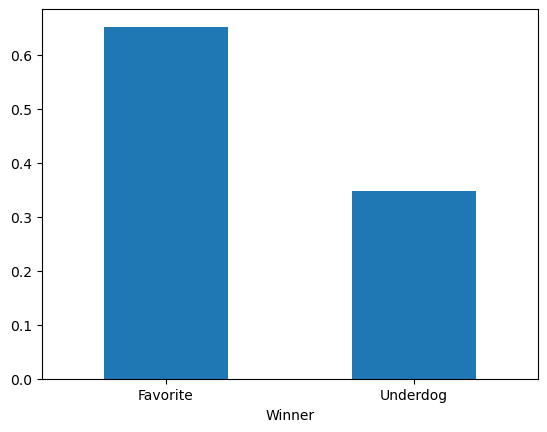

In [11]:
percentage_breakdown.plot(kind='bar', rot=0)

In [12]:
# Statistical overview of dataset
df.describe()

,height_delta,reach_delta,SLPM_delta,Str Acc_delta,SApm_delta,Str. Def_delta,TD Avg_delta,TD Acc_delta,TD Def_delta,Sub Avg_delta,age_delta,Odds_Delta
count,4332.000000,4332.000000,4332.00000,4332.000000,4332.000000,4332.000000,4332.000000,4332.000000,4332.000000,4332.000000,4332.000000,4332.000000
mean,0.015235,0.044321,0.11867,0.005524,-0.171205,0.012052,0.102281,0.015748,0.018827,0.050016,0.101916,-0.606265
std,2.509138,3.264578,1.62991,0.101050,1.701383,0.122555,1.762903,0.262499,0.296302,0.861009,5.344499,2.190376
min,-12.000000,-14.000000,-6.75000,-0.500000,-39.370000,-0.630000,-9.890000,-1.000000,-1.000000,-5.400000,-26.000000,-12.950000
25%,-2.000000,-2.000000,-0.94000,-0.060000,-1.092500,-0.050000,-0.880000,-0.140000,-0.150000,-0.300000,-4.000000,-1.700000
50%,0.000000,0.000000,0.11000,0.000000,-0.130000,0.010000,0.080000,0.010000,0.020000,0.000000,0.000000,-0.540000
75%,2.000000,2.000000,1.16000,0.070000,0.850000,0.070000,1.090000,0.170000,0.180000,0.400000,4.000000,0.720000
max,11.000000,13.000000,8.99000,0.510000,8.180000,5.160000,8.220000,1.000000,5.070000,11.800000,18.000000,9.660000


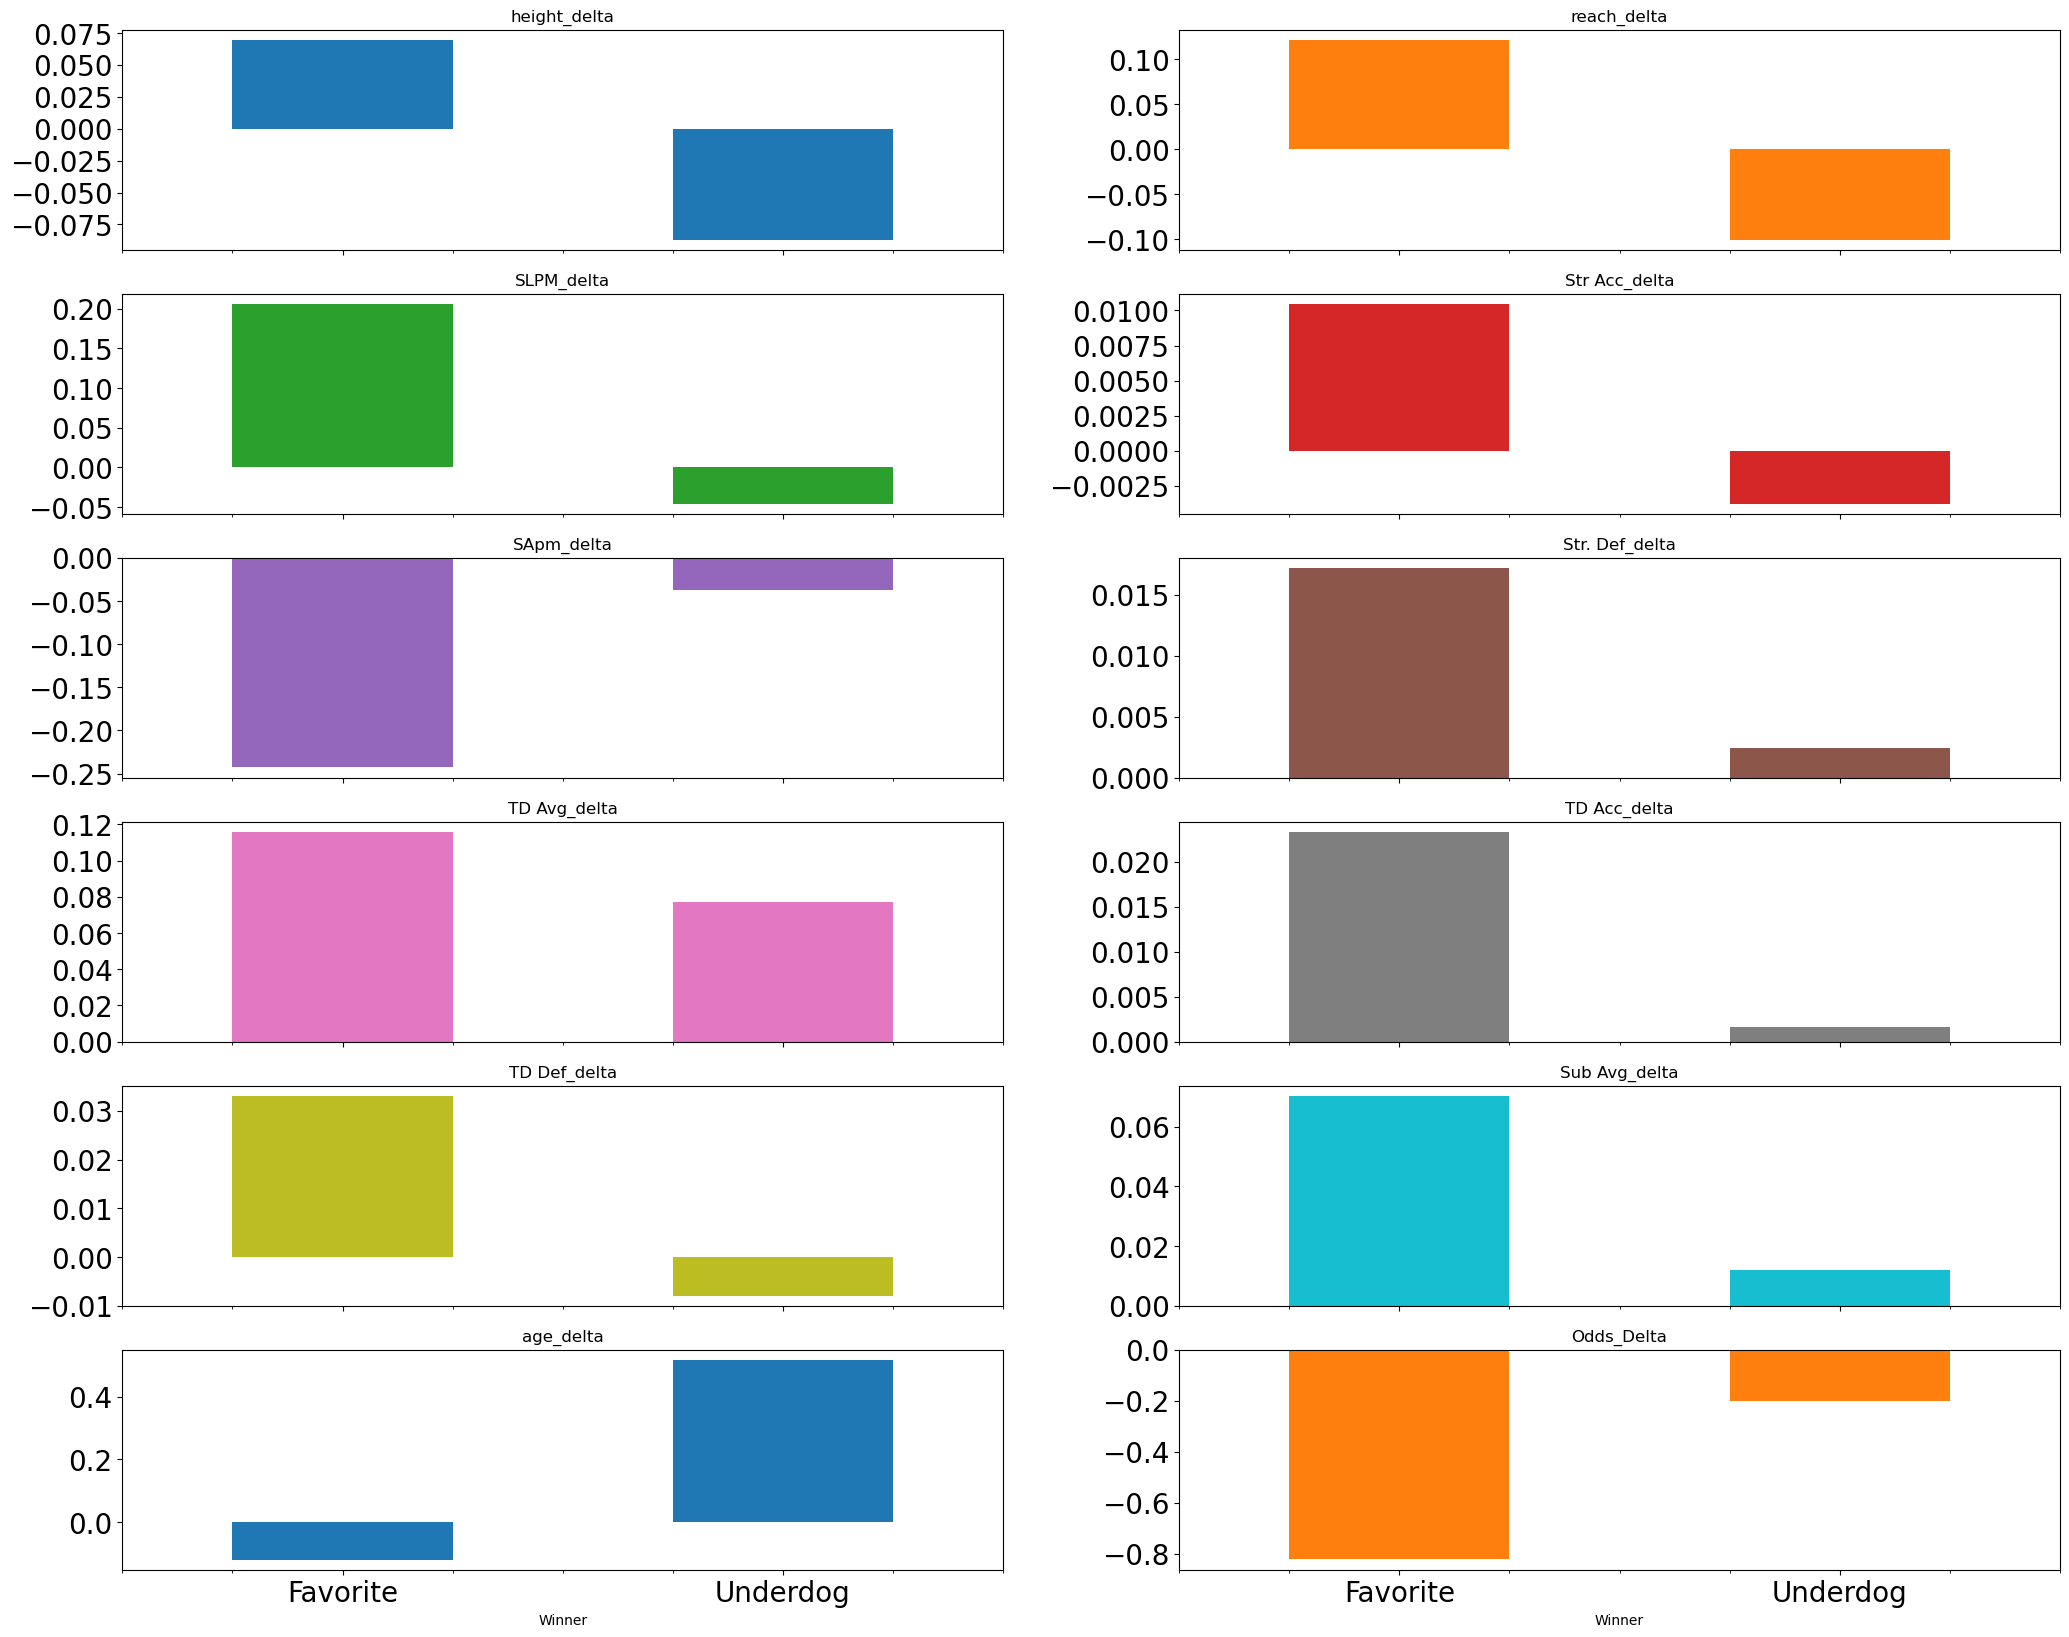

In [13]:
import matplotlib.pyplot as plt

# Assuming df is your DataFrame
# Ensure 'Winner' column exists and contains the groups

# Filter only numeric columns
numeric_df = df.select_dtypes(include='number')

# Include 'Winner' column for grouping
numeric_df['Winner'] = df['Winner']

# Group by 'Winner' and calculate the mean
mean_df = numeric_df.groupby('Winner').mean()

# Adjust layout to fit all subplots
mean_df.plot(kind='bar', subplots=True, layout=(6, 2), legend=False, figsize=(25, 20), fontsize=20, rot=0)
plt.show()

In [14]:
def create_dummies(df, column_name):
    """Create Dummy Columns (One Hot Encoding) from a single Column
    
    Usage
    ------
    train = create_dummies(train, "Age")
    """
    # Create dummy variables for the specified column
    dummies = pd.get_dummies(df[column_name], prefix=column_name)
    # Concatenate the dummy variables to the original DataFrame
    df = pd.concat([df, dummies], axis=1)
    return df

# Create dummy variables for the 'Winner' column
df_corr = create_dummies(df, 'Winner')

# Print the DataFrame with dummy variables
print(df_corr)

# Drop the 'Event' column as it contains non-numeric data
df_corr = df_corr.drop('Event Title', axis=1)
df_corr = create_dummies(df, 'Winner').drop('Winner_Underdog', axis = 1)
# Ensure only numeric columns are used for correlation calculation
df_corr = df_corr.select_dtypes(include=[float, int, bool])

# Calculate the correlation matrix for the remaining columns
corr = df_corr.corr()

corr = (corr)
corr

                              Event Title            Underdog  \
0              UFC 159 - Jones vs. Sonnen        Chael Sonnen   
1              UFC 159 - Jones vs. Sonnen        Alan Belcher   
2              UFC 159 - Jones vs. Sonnen        Cheick Kongo   
3              UFC 159 - Jones vs. Sonnen     Vinny Magalhaes   
4              UFC 159 - Jones vs. Sonnen           Pat Healy   
...                                   ...                 ...   
4327  UFC Fight Night: Barboza vs. Murphy       Tamires Vidal   
4328  UFC Fight Night: Barboza vs. Murphy       Warlley Alves   
4329  UFC Fight Night: Barboza vs. Murphy   Ariane Carnelossi   
4330  UFC Fight Night: Barboza vs. Murphy       Heili Alateng   
4331  UFC Fight Night: Barboza vs. Murphy  Vanessa Demopoulos   

                  Favorite    Winner  height_delta  reach_delta  SLPM_delta  \
0                Jon Jones  Favorite             3           11        1.21   
1          Michael Bisping  Favorite            -1           

,height_delta,reach_delta,SLPM_delta,Str Acc_delta,SApm_delta,Str. Def_delta,TD Avg_delta,TD Acc_delta,TD Def_delta,Sub Avg_delta,age_delta,Odds_Delta,Winner_Favorite
height_delta,1.000000,0.618667,0.106800,0.051101,-0.016692,-0.090137,-0.134353,0.011996,-0.034399,0.117204,-0.119419,-0.040053,0.029743
reach_delta,0.618667,1.000000,0.062963,-0.025974,-0.047837,-0.073318,-0.070920,0.055436,-0.004770,0.057194,-0.107147,-0.074406,0.032335
SLPM_delta,0.106800,0.062963,1.000000,0.339563,0.273202,0.150815,-0.179200,0.040954,0.265467,-0.150569,-0.203008,-0.197857,0.073679
Str Acc_delta,0.051101,-0.025974,0.339563,1.000000,-0.196426,0.108688,0.160977,0.225384,0.149847,0.101599,-0.077908,-0.233095,0.067209
SApm_delta,-0.016692,-0.047837,0.273202,-0.196426,1.000000,-0.268255,-0.289918,-0.172155,-0.057270,-0.093954,-0.021543,0.205639,-0.057473
Str. Def_delta,-0.090137,-0.073318,0.150815,0.108688,-0.268255,1.000000,0.028037,0.078725,0.179576,-0.111366,0.029154,-0.154161,0.057201
TD Avg_delta,-0.134353,-0.070920,-0.179200,0.160977,-0.289918,0.028037,1.000000,0.378597,0.036503,0.189057,-0.046576,-0.186763,0.010410
TD Acc_delta,0.011996,0.055436,0.040954,0.225384,-0.172155,0.078725,0.378597,1.000000,0.196801,0.029827,-0.053720,-0.178408,0.039257
TD Def_delta,-0.034399,-0.004770,0.265467,0.149847,-0.057270,0.179576,0.036503,0.196801,1.000000,-0.199583,-0.051445,-0.204924,0.066041
Sub Avg_delta,0.117204,0.057194,-0.150569,0.101599,-0.093954,-0.111366,0.189057,0.029827,-0.199583,1.000000,-0.043256,-0.079406,0.032124


<Axes: >

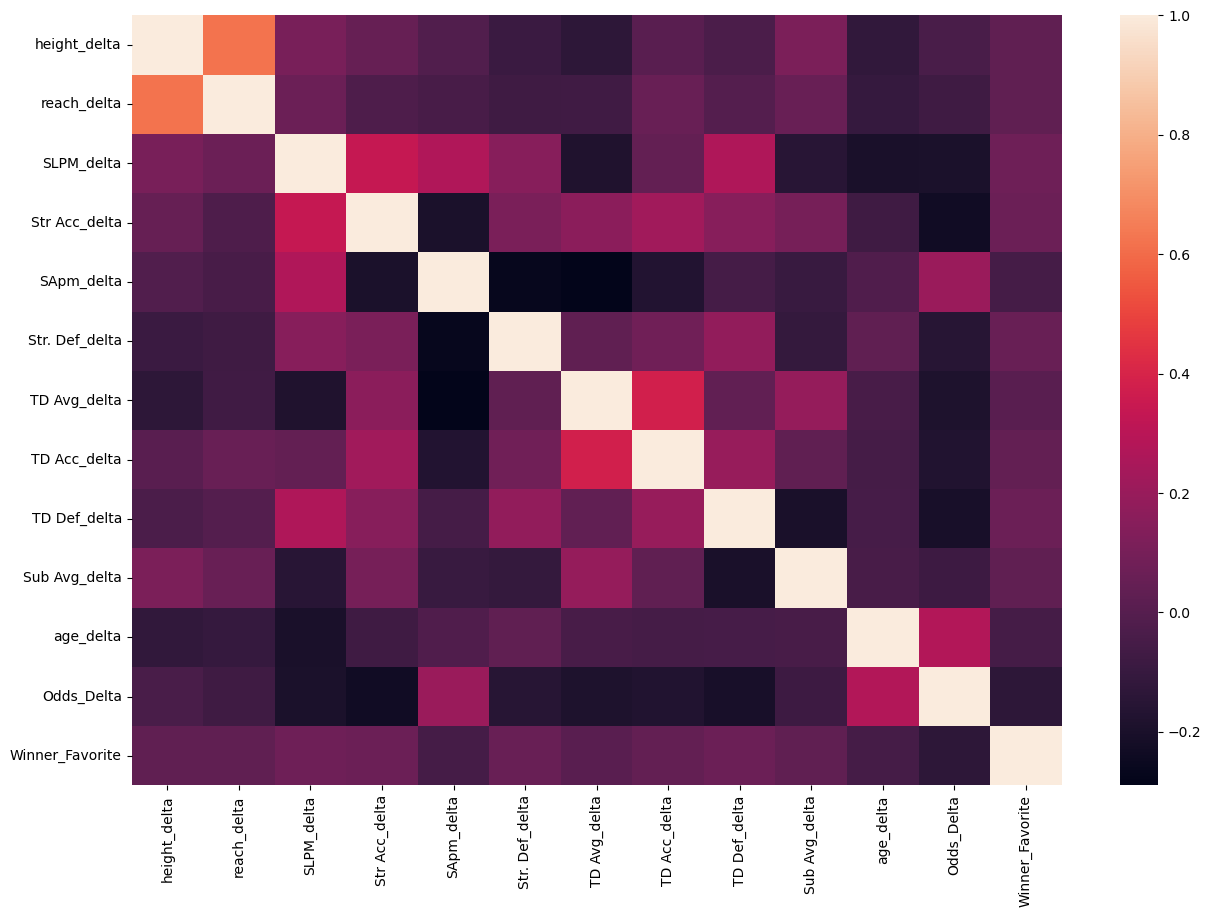

In [15]:
plt.figure(figsize=(15,10))
sns.heatmap(corr, 
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values)

In [16]:
# Compating both means

print('STRD_delta mean of favourite winners is: ' +  '{}' .format(df['Str Acc_delta'][df['Winner'] == 'Favorite'].mean()))
print('STRD_delta mean of underdog winners is: ' + '{}'.format(df['Str Acc_delta'][df['Winner'] == 'Underdog'].mean()))

# However, is the marginal difference of 0.047 significant? 

STRD_delta mean of favourite winners is: 0.010481245576786978
STRD_delta mean of underdog winners is: -0.0037782204515272254


In [17]:
# T-test
print(df.columns)
stats.ttest_1samp(a=  df[df['Winner']=='Favorite']['Str Acc_delta'], # Sample of Favourite winners
                  popmean = df['Str Acc_delta'].mean())  # Fighter population mean 

Index(['Event Title', 'Underdog', 'Favorite', 'Winner', 'height_delta',
       'reach_delta', 'SLPM_delta', 'Str Acc_delta', 'SApm_delta',
       'Str. Def_delta', 'TD Avg_delta', 'TD Acc_delta', 'TD Def_delta',
       'Sub Avg_delta', 'age_delta', 'Odds_Delta'],
      dtype='object')


TtestResult(statistic=2.5178613423868583, pvalue=0.011861847998437517, df=2825)

In [18]:
# Critical point 
degree_freedom = len(df[df['Winner']=='Favorite'])

LQ = stats.t.ppf(0.025,degree_freedom)  # Left Quartile

RQ = stats.t.ppf(0.975,degree_freedom)  # Right Quartile

print ('The t-distribution left quartile range is: ' + str(LQ))
print ('The t-distribution right quartile range is: ' + str(RQ))

The t-distribution left quartile range is: -1.9608037829517349
The t-distribution right quartile range is: 1.9608037829517344


In [19]:
cols = df.drop(['Event Title', 'Favorite', 'Underdog', 'Winner'], axis =1).columns.tolist()

IndexError: index 2 is out of bounds for axis 0 with size 2

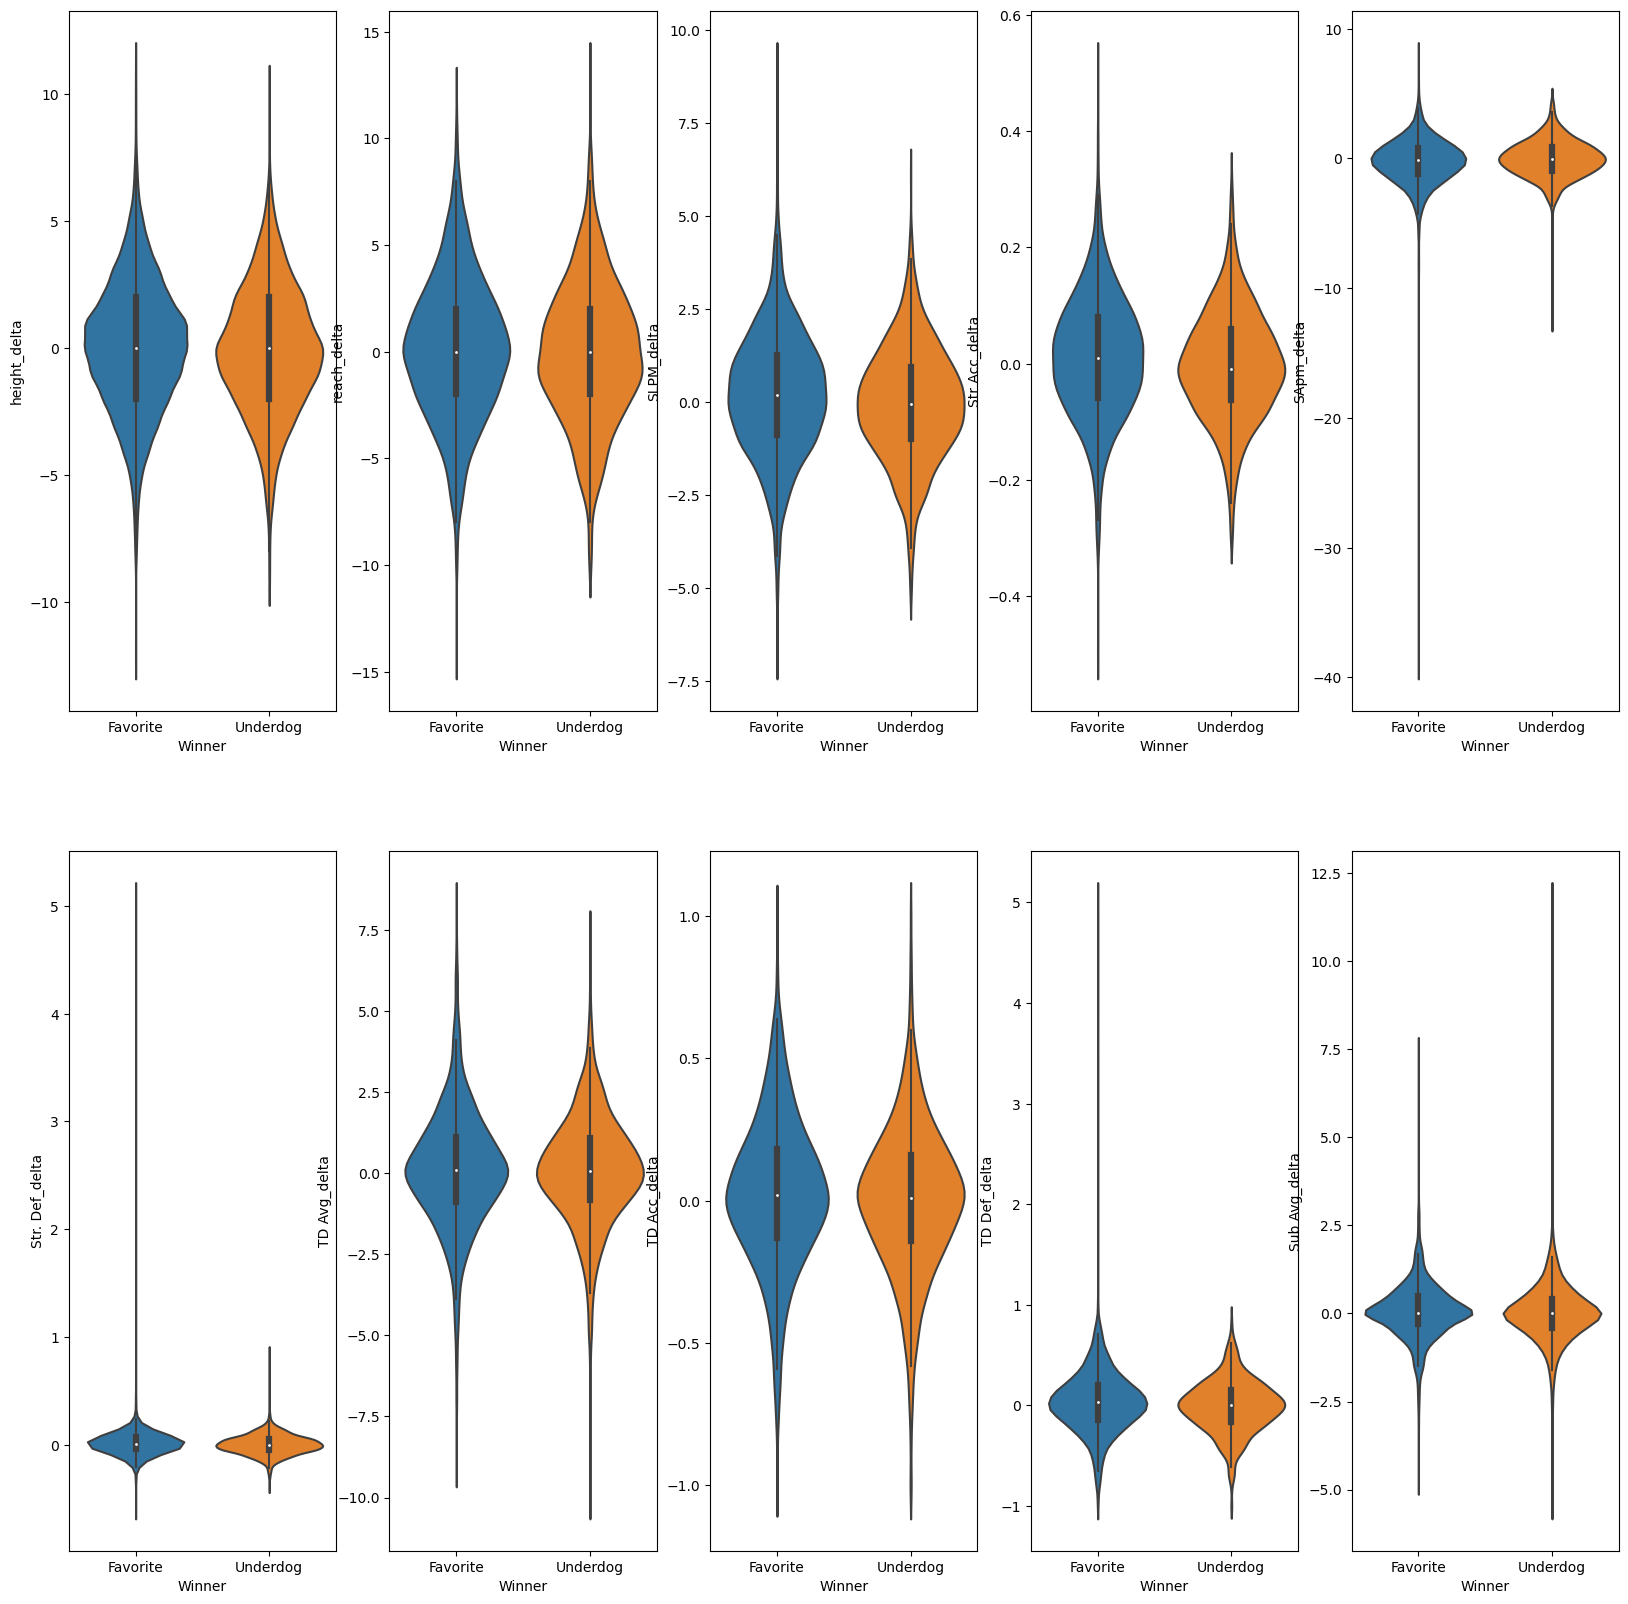

In [40]:
# create 10 plots with a 2 by 5 dimension subplots
fig, ax = plt.subplots(2,5, figsize=(20,20))

# loop to plot in subplots
for i, col in enumerate(cols):
    x = i // 5
    y = i % 5
    sns.violinplot(x="Winner", y=col , data=df, order=["Favorite", "Underdog"], ax=ax[x,y])

In [22]:
# Create a function to select features
# Note that feature names are stored in cols
def select_features(df):
    all_X = df.drop(['Event Title', 'Favorite', 'Underdog', 'Winner'], axis=1)
    all_y = df['Winner']
    
    clf = RandomForestClassifier(random_state=1)
    selector = RFECV(clf)
    selector.fit(all_X, all_y)
    best_columns = list(all_X.columns[selector.support_])
    print('Best Columns \n' + '-'*12 + '\n' + '{}'.format(best_columns))
    
    return best_columns

In [23]:
best_cols = select_features(df)

Best Columns 
------------
['SLPM_delta', 'Str Acc_delta', 'SApm_delta', 'Str. Def_delta', 'TD Avg_delta', 'TD Acc_delta', 'TD Def_delta', 'Sub Avg_delta', 'Odds_Delta']


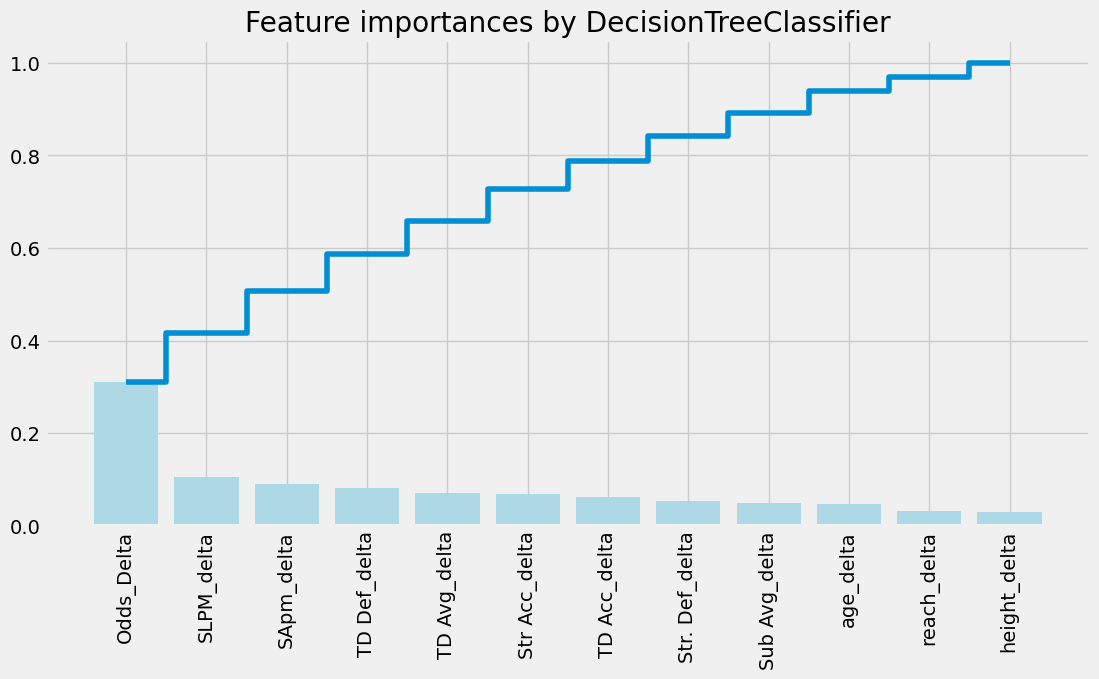

In [27]:
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (12,6)

# Create train and test splits
target_name = 'Winner'
X = df.drop(['Event Title', 'Favorite', 'Underdog', 'Winner'], axis=1)


y=df[target_name]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.15, random_state=1, stratify=y)

dtree = RandomForestClassifier(
    #max_depth=3,
    random_state = 1,
    class_weight="balanced",
    min_weight_fraction_leaf=0.01
    )
dtree = dtree.fit(X_train,y_train)

## plot the importances ##
importances = dtree.feature_importances_
feat_names = df.drop(['Event Title', 'Favorite', 'Underdog', 'Winner'], axis=1).columns


indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12,6))
plt.title("Feature importances by DecisionTreeClassifier")
plt.bar(range(len(indices)), importances[indices], color='lightblue',  align="center")
plt.step(range(len(indices)), np.cumsum(importances[indices]), where='mid', label='Cumulative')
plt.xticks(range(len(indices)), feat_names[indices], rotation='vertical',fontsize=14)
plt.xlim([-1, len(indices)])
plt.show()

In [33]:
def select_model(df, features):
    
    all_X = df[features]
    all_y = df["Winner"]
    #create a list of dics which contains models and hyperparameters
    models = [
        
        {
            "name": "Logistic Regression",
            "estimator": LogisticRegression(random_state=1),
            "hyperparameters": {
                "C": [0.01, 0.1, 1, 10, 100],
                "penalty": ["l1", "l2", "elasticnet"],
                "solver": ["newton-cg", "lbfgs", "liblinear", "saga"],
                "class_weight": [None, "balanced"],
                "max_iter": [100, 200, 500]
            }
        },

        {
            "name": "RandomForestClassifier",
            "estimator": RandomForestClassifier(random_state=1),
            "hyperparameters": {
                "n_estimators": [50, 100],
                "criterion": ["entropy", "gini"],
                "max_depth": [10, 20],
                "max_features": ["log2", "sqrt", "auto"],
                "min_samples_leaf": [1, 5],
                "min_samples_split": [2, 5]
            }
        },
                {
    "name": "Multi Layer Perceptron (MLP)",
    "estimator": MLPClassifier(random_state=1),
    "hyperparameters": {
        "hidden_layer_sizes": [(10, 10), (20, 20), (30, 30)],
        "activation": ["relu", "tanh"],
        "solver": ['sgd', 'adam'],
        "learning_rate": ["constant", "adaptive"],
        "alpha": [0.0001, 0.001, 0.01]
            }
        }
        
    ]
    
    for model in log_progress(models):
        print(model["name"])
        print("-"*len(model["name"]))
        
        grid = GridSearchCV(model["estimator"],
                            param_grid=model["hyperparameters"],
                            cv=10, scoring = 'accuracy')
        grid.fit(all_X,all_y)
        model["best_params"] = grid.best_params_
        model["best_score"] = grid.best_score_
        model["best_model"] = grid.best_estimator_
        model["scoring"] = grid.scorer_
        
        print("Best Paramerters:\n" + "{}".format(model["best_params"]))
        print("Best Score:\n" + "{}".format(model["best_score"]))
        print("Best Model:\n" + "{}\n".format(model["best_model"]))
        print("Scoring method:\n" + "{}\n".format(model["scoring"]))
        
    return models

In [34]:
models = select_model(df, best_cols)

Logistic Regression
-------------------
Best Paramerters:
{'C': 0.01, 'class_weight': None, 'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}
Best Score:
0.6449665286661488
Best Model:
LogisticRegression(C=0.01, penalty='l1', random_state=1, solver='saga')

Scoring method:
make_scorer(accuracy_score)

RandomForestClassifier
----------------------
Best Paramerters:
{'criterion': 'entropy', 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best Score:
0.6507396685859027
Best Model:
RandomForestClassifier(criterion='entropy', max_depth=10, max_features='log2',
                       n_estimators=50, random_state=1)

Scoring method:
make_scorer(accuracy_score)

Multi Layer Perceptron (MLP)
----------------------------
Best Paramerters:
{'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (20, 20), 'learning_rate': 'adaptive', 'solver': 'sgd'}
Best Score:
0.660893349368355
Best Model:
MLPClassifier(alpha=0.01, hidden_layer_s